# Reproducing baseline Tg prediction
Here we replicate the prediction results from Rasulev 2024 Nature paper.

Using training and test data w/ target variable: log(Tg) and features: 15 descriptors.

Source: https://github.com/bakhras/ml_Tg_predictor

In [1]:
import sys
from pathlib import Path
import pandas as pd
pd.set_option('display.max_colwidth', 100)  # Limit to 100 characters

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Ensure project root is on path (one level up from 'development')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Also add the shared directory so that `utils` package can be resolved (matches streamlit_app logic)
SHARED_DIR = PROJECT_ROOT / 'shared'
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor


# Load data
Read CSV files saved locally from URL

In [5]:
train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / "data_902_original_15desc_logTg_train.csv")  # Local file path

In [6]:
train_df.head()

,No,Index,nCsp2,SpMax_EA(ri),SpMax_AEA(dm),SM11_EA,Eig03_EA,B03[C-N],S1K,piPC05,piPC07,AAC,SIC4,SpDiam_B(e),SpMax1_Bh(i),Mor31v,TE1,logTg,Series
0,1,PPD_007,1,1.568,3.150,8.507,-1.000,0,4.494,0.000,0.000,0.722,0.000,4.599,3.374,0.079,1.028,2.7077,T
1,2,PPD_008,1,2.352,3.621,8.507,-1.000,1,3.948,0.000,0.000,1.371,0.000,4.608,3.425,0.023,2.840,2.8520,T
2,3,PPD_010,2,2.446,4.150,10.289,0.821,1,8.896,2.565,2.197,1.096,1.000,4.766,3.443,0.161,5.075,2.8177,T
3,5,PPD_019,1,2.378,3.898,9.304,0.471,0,6.468,2.485,0.000,1.299,0.875,4.717,3.427,0.031,3.641,2.7552,T
4,6,PPD_029,1,2.379,3.779,9.306,1.887,0,18.221,3.045,2.944,0.426,0.726,4.656,3.383,1.177,10.695,2.7687,T


In [75]:
(train_df['Index']=='BWN_257').sum()

1

In [7]:
test_df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / "data_c219_Tg_test.csv")

In [8]:
test_df.head()

,No,logTg,nCsp2,SpMax_EA(ri),SpMax_AEA(dm),SM11_EA,Eig03_EA,B03[C-N],S1K,piPC05,piPC07,AAC,SIC4,SpDiam_B(e),SpMax1_Bh(i),Mor31v,TE1
0,1,2.7178,0.074074,0.797028,0.808405,0.811272,0.585265,0,0.178967,0.351211,0.187420,0.832288,0.907,0.667689,0.636364,0.526942,0.949016
1,2,2.7854,0.000000,0.777134,0.593750,0.758583,0.085679,0,0.069872,0.000000,0.000000,0.000000,0.000,0.617076,0.528796,0.558900,0.944596
2,3,2.7317,0.000000,0.285319,0.717457,0.000000,0.164735,0,0.061663,0.000000,0.000000,0.411865,0.400,0.440184,0.354593,0.515793,0.943993
3,4,2.5577,0.148148,0.883908,0.705172,0.867878,0.807740,0,0.296866,0.738488,0.683285,0.424415,0.984,0.839213,0.827225,0.473430,0.952442
4,5,2.4364,0.074074,0.642156,0.599353,0.661710,0.578228,0,0.151329,0.292388,0.226674,0.625214,0.947,0.687628,0.665873,0.580453,0.949632


plot distributions of log Tg

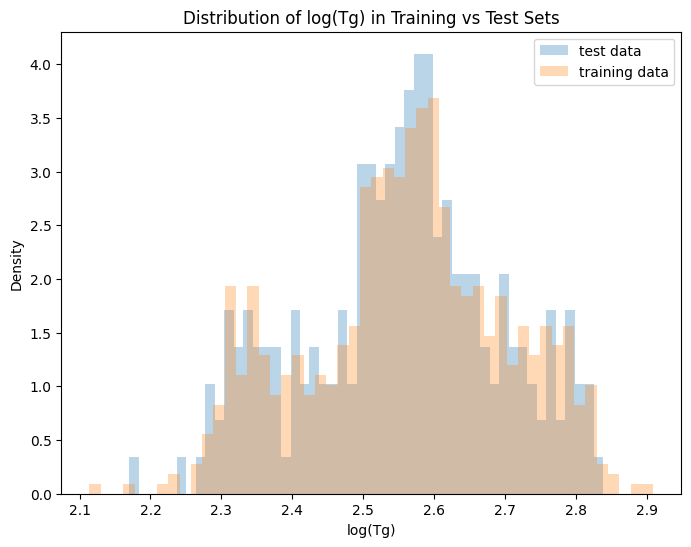

In [9]:
plt.figure(figsize=(8,6))
sns.histplot(
    test_df['logTg'],
    bins=50,
    label='test data',
    stat='density',  # Normalize to show probability density
    alpha=0.3,
    edgecolor='none'  # Remove edges
)
sns.histplot(
    train_df['logTg'],
    bins=50,
    label='training data',
    stat='density',  # Normalize to show probability density
    alpha=0.3,
    edgecolor='none'  # Remove edges
)
plt.xlabel('log(Tg)')
plt.ylabel('Density')
plt.title('Distribution of log(Tg) in Training vs Test Sets')
plt.legend()
plt.show()

In [10]:
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [11]:
feat_cols = [
    col_ for col_ in train_df.columns if col_ not in ['No','Index','logTg','Series']
]

In [12]:
feat_cols

['nCsp2',
 'SpMax_EA(ri)',
 'SpMax_AEA(dm)',
 'SM11_EA',
 'Eig03_EA',
 'B03[C-N]',
 'S1K',
 'piPC05',
 'piPC07',
 'AAC',
 'SIC4',
 'SpDiam_B(e)',
 'SpMax1_Bh(i)',
 'Mor31v',
 'TE1']

In [13]:
y_train = train_df['logTg'].values
X_train = train_df[feat_cols].values

In [14]:
X_train.shape

(683, 15)

In [15]:
y_train.shape

(683,)

In [16]:
scaler_x_train = StandardScaler().fit(X_train)
scaler_y_train = StandardScaler().fit(y_train.reshape(-1, 1))

In [17]:
X_train_scaled = scaler_x_train.transform(X_train)
y_train_scaled = scaler_y_train.transform(y_train.reshape(-1, 1))

In [18]:
X_train_scaled.shape

(683, 15)

In [19]:
y_train_scaled.shape

(683, 1)

In [20]:
y_test = test_df['logTg'].values
X_test = test_df[feat_cols].values

In [21]:
X_test.shape

(219, 15)

In [22]:
y_test.shape

(219,)

In [23]:
scaler_x_test = StandardScaler().fit(X_test)
scaler_y_test = StandardScaler().fit(y_test.reshape(-1, 1))

In [24]:
X_test_scaled = scaler_x_test.transform(X_test)
y_test_scaled = scaler_y_test.transform(y_test.reshape(-1, 1))[:,0]

In [25]:
X_test_scaled.shape

(219, 15)

In [26]:
y_test_scaled.shape

(219,)

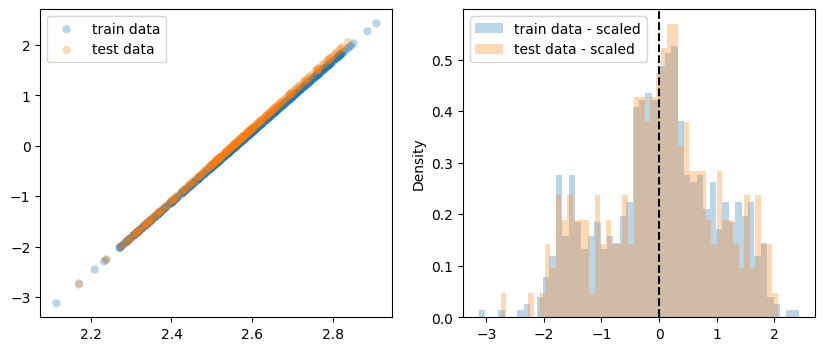

In [27]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(
    y_train,
    y_train_scaled,
    label='train data',
    alpha=0.3,
    edgecolor='none'
)
plt.scatter(
    y_test,
    y_test_scaled,
    label='test data',
    alpha=0.3,
    edgecolor='none'
)
plt.legend()
plt.subplot(1, 2, 2)
sns.histplot(
    y_train_scaled,
    bins=50,
    label='train data - scaled',
    stat='density',  # Normalize to show probability density
    alpha=0.3,
    edgecolor='none'  # Remove edges
)
sns.histplot(
    y_test_scaled,
    bins=50,
    label='test data - scaled',
    stat='density',  # Normalize to show probability density
    alpha=0.3,
    edgecolor='none'  # Remove edges
)
plt.axvline(x=0, linestyle='--', color='k')
plt.legend()
plt.show()

# Support Vector Regressor
It is a strong regression technique to fit a model of continuous variable based on set of features. It involves a kernel function meaning what kind of relationship nearby data-points have like linear or non-linear. 
* Then it has a epsilon parameter which defines a tube around the model function where no penalty is applied meaning if the model prediction value and real value are epsilon apart then it's fine.
* Then beyond the epsilon tube we have the outliers and **support vectors** drawn from the epsilon tube edge to the outlier data-point.
* The goal is to minimize the support vectors but also to keep model function as simple as possible (trivial case: y=b)

For the current case, we don't know whether the descriptors impact the target variable linearly or non-linearly. But the target variable is normally distributed. Using a **radial basis function** as a kernel would fit a model where features that are radially close to each other will yeild a similar target variable. Hence, we define the 3 key model parameters,
* **epsilon**: no penalty is associated in the training loss function with points predicted within a distance epsilon from the actual value. Ideally small but relax it if training fit performance is bad.
* **C**: capacity constant used for regularization. Increasing this makes the contribution of outliers stronger in optimization. Increasing will improve training model fit but lead to overfitting. Reduce C for regularization.
* **gamma**: The radial basis function is defined as exp(-gamma* (x_i - x_j)^2) where x_i and x_j are input features. Gamma is 1/variance thus defining the spread of the radial function. At Large Gamma even nearby features would yield different results. Smaller gamma means more generalized radial distribution with respect to input features. Reduce gamma for regularization.

## Loading the SVM model within supplementary data
We will look into the paramters used for regression modelling

In [28]:
import pickle

In [29]:
with open(PROJECT_ROOT / 'data' / 'raw' / 'svr_model.pickle', 'rb') as file:
    # Load the SVR model from the file
    loaded_svr_model = pickle.load(file)

/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVR from version 1.3.0 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [30]:
loaded_svr_model

,kernel,'rbf'
,degree,3
,gamma,1.1
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.031
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## SVM regressor's hyperparameters
* Within supplementary text the  kernel mentioned is 'rbf' and C = 1, gamma = 5, but within model pickle file: C = 10, gamma = 1.1. So we check both set of values.
* Additionally the text didn't mention an epsilon value but the model has 0.031. The default value in scikit learn is 0.1 which is much relaxed.
* review R2 score for each case.

In [31]:
def test_model_fit(X_scaled, y_scaled, C_, gamma_, epsilon):
    print(f"C: {C_}; gamma: {gamma_:.2f}; epsilon: {epsilon}")
    regr = SVR(
        kernel='rbf',C=C_, gamma=gamma_,epsilon=epsilon
    )
    SVM_fit_model = regr.fit(X_scaled, y_scaled)
    
    y_pred = SVM_fit_model.predict(X_scaled)
    
    print(f'Training fit R2-score: {r2_score(y_scaled, y_pred):.2f}')
    
    return SVM_fit_model, y_pred

In [32]:
_ = test_model_fit(
    X_scaled=X_train_scaled,
    y_scaled=y_train_scaled,
    C_=1,
    gamma_=5,
    epsilon=0.1
)

C: 1; gamma: 5.00; epsilon: 0.1
Training fit R2-score: 0.89


/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [33]:
_ = test_model_fit(
    X_scaled=X_train_scaled,
    y_scaled=y_train_scaled,
    C_=1,
    gamma_=5,
    epsilon=0.031
)

C: 1; gamma: 5.00; epsilon: 0.031
Training fit R2-score: 0.90


/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [34]:
_ = test_model_fit(
    X_scaled=X_train_scaled,
    y_scaled=y_train_scaled,
    C_=10,
    gamma_=1.1,
    epsilon=0.031
)

/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


C: 10; gamma: 1.10; epsilon: 0.031
Training fit R2-score: 0.99


In [35]:
_ = test_model_fit(
    X_scaled=X_train_scaled,
    y_scaled=y_train_scaled,
    C_=10,
    gamma_=1.1,
    epsilon=0.1
)

C: 10; gamma: 1.10; epsilon: 0.1


/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Training fit R2-score: 0.98


### Best model - rmse training
Using C = 10; gamma = 1.1 and epsilon = 0.031 as per the pickle file in github repo.

In [36]:
SVM_best_fit, y_train_scaled_pred = test_model_fit(
    X_scaled=X_train_scaled,
    y_scaled=y_train_scaled,
    C_=10,
    gamma_=1.1,
    epsilon=0.031
)

C: 10; gamma: 1.10; epsilon: 0.031


/home/vidit-agrawal/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Training fit R2-score: 0.99


In [38]:
y_train_pred = scaler_y_train.inverse_transform(y_train_scaled_pred.reshape((-1, 1)))

In [39]:
f"{r2_score(y_train, y_train_pred):.2f}"

'0.99'

In [40]:
print(f"Root mean squared error: {root_mean_squared_error(y_train, y_train_pred):.3f}")

Root mean squared error: 0.014


### Best model - training data - target vs. predicted values

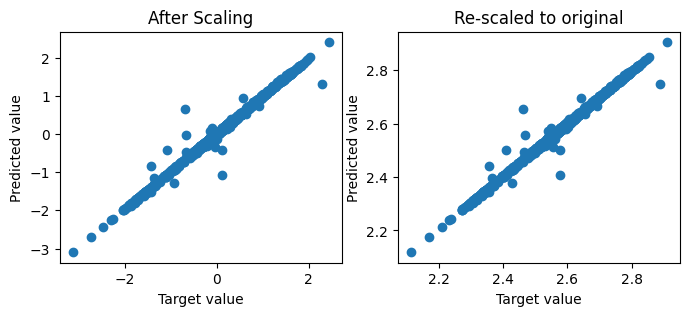

In [41]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.scatter(
    y_train_scaled,
    y_train_scaled_pred,
)
plt.title('After Scaling')
plt.ylabel('Predicted value')
plt.xlabel('Target value')
plt.subplot(1, 2, 2)
plt.scatter(
    y_train,
    y_train_pred,
    label='Target vs. predicted'
)
plt.title('Re-scaled to original')
plt.ylabel('Predicted value')
plt.xlabel('Target value')
plt.show()

## Validating model on independent test dataset

In [42]:
y_test_scaled_pred = SVM_best_fit.predict(X_test_scaled)

In [43]:
y_test_pred = scaler_y_test.inverse_transform(y_test_scaled_pred.reshape((-1, 1)))

In [44]:
y_test_pred.shape

(219, 1)

In [45]:
r2_score(y_test_scaled, y_test_scaled_pred)

0.7320528401813939

In [46]:
r2_score(y_test, y_test_pred)

0.7320528401813939

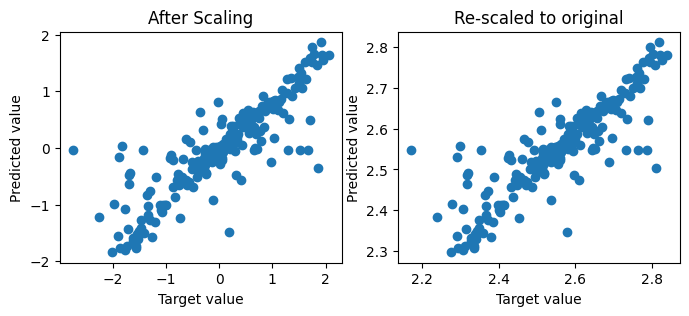

In [47]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.scatter(
    y_test_scaled,
    y_test_scaled_pred,
)
plt.title('After Scaling')
plt.ylabel('Predicted value')
plt.xlabel('Target value')
plt.subplot(1, 2, 2)
plt.scatter(
    y_test,
    y_test_pred,
    label='Target vs. predicted'
)
plt.title('Re-scaled to original')
plt.ylabel('Predicted value')
plt.xlabel('Target value')
plt.show()

## Visualizing ALE plots
Accumulated Local Effects (ALE) for SVM regressor visualizes the marginal effect of a feature on the predicted outcome, while accounting for correlations with other features.
* Calculate the difference in the prediction when the feature value is replaced with the upper and lower limit of the interval. 

In [48]:
feat_cols

['nCsp2',
 'SpMax_EA(ri)',
 'SpMax_AEA(dm)',
 'SM11_EA',
 'Eig03_EA',
 'B03[C-N]',
 'S1K',
 'piPC05',
 'piPC07',
 'AAC',
 'SIC4',
 'SpDiam_B(e)',
 'SpMax1_Bh(i)',
 'Mor31v',
 'TE1']

In [50]:
SVM_best_fit

,kernel,'rbf'
,degree,3
,gamma,1.1
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.031
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [70]:
X_train_scaled.shape

(683, 15)

In [73]:
def get_ALE(X, model_fit, feat_index=0, num_intervals = 10):

    # initialize array to save ALE values
    ale_values = np.zeros(num_intervals)
    # feature vector
    X_feat = X[:,feat_index]
    # Create intervals for the chosen feature
    interval_edges = np.linspace(
        X_feat.min(), X_feat.max(), num_intervals + 1
    )
    # loop over the range of feature values defined via intervals 
    for i in range(num_intervals):
        # Find data points within the current interval
        mask = (X_feat >= interval_edges[i]) & (X_feat < interval_edges[i+1])
    
        if np.any(mask):
            X_interval_lower = X[mask,:].copy()
            X_interval_lower[:,feature_index] = X[mask,feature_index].min()
            predictions_lower = model_fit.predict(X_interval_lower)
            
            X_interval_upper = X[mask,:].copy()
            X_interval_upper[:,feature_index] = X[mask,feature_index].max()
            predictions_upper = model_fit.predict(X_interval_upper)
            
            # Average local effect for the interval
            ale_values[i] = np.mean(predictions_upper - predictions_lower)
    
    plt.figure(figsize=(4, 3))
    plt.plot(
        interval_edges[:-1],
        ale_values
    )
    plt.xlabel('Input feature value')
    plt.ylabel('ALE (accumulated local effect)')
    plt.show()

nCsp2


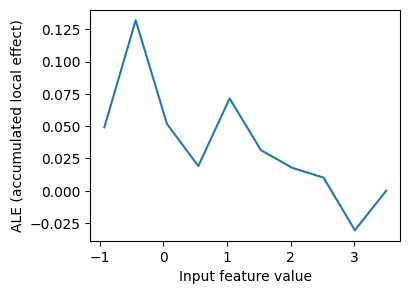

SpMax_EA(ri)


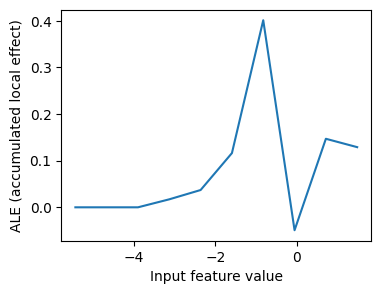

SpMax_AEA(dm)


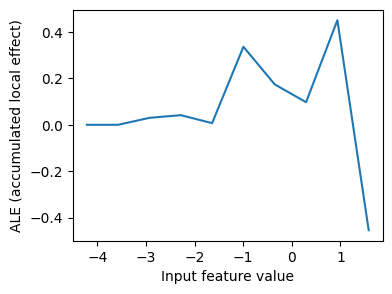

SM11_EA


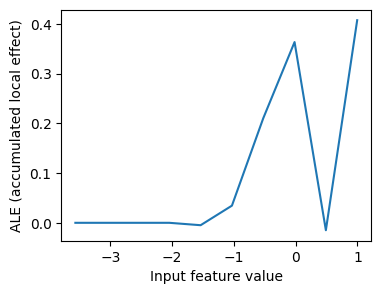

Eig03_EA


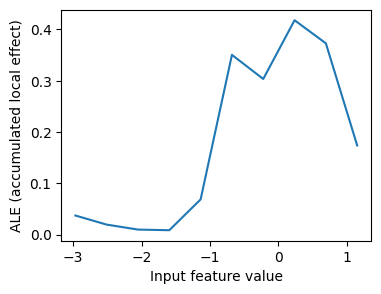

B03[C-N]


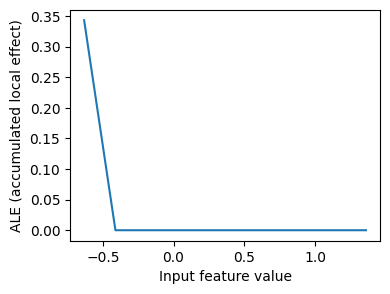

S1K


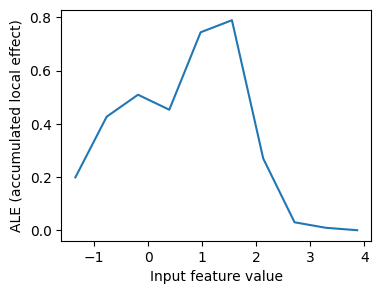

piPC05


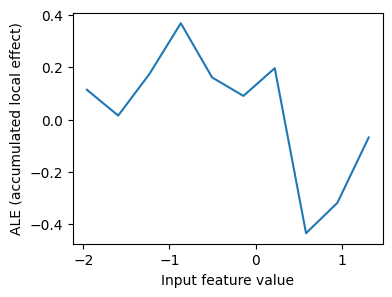

piPC07


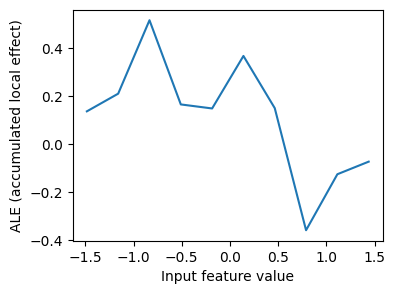

AAC


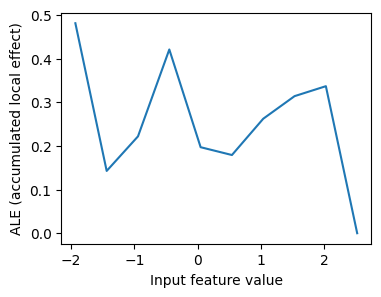

SIC4


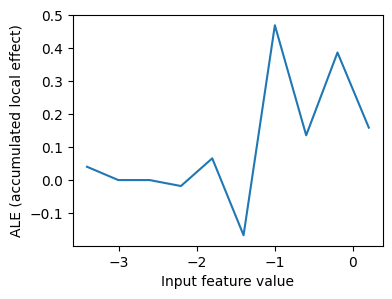

SpDiam_B(e)


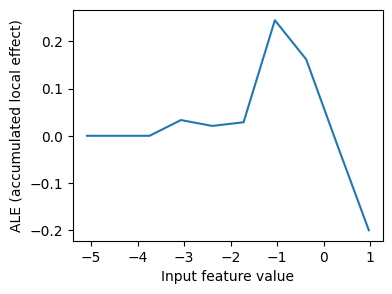

SpMax1_Bh(i)


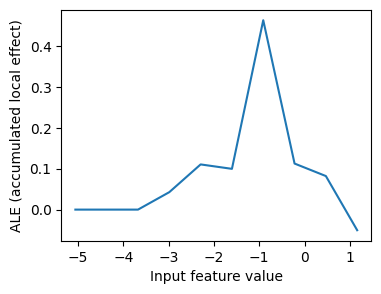

Mor31v


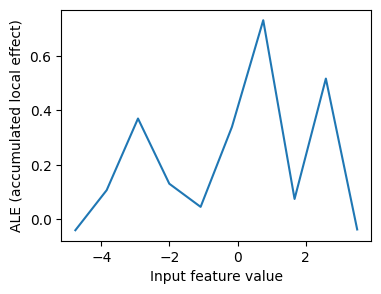

TE1


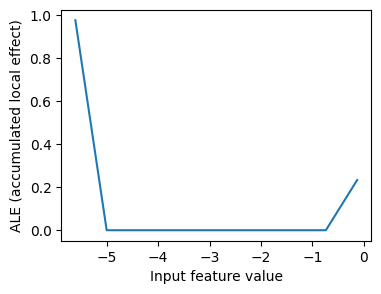

In [74]:
for i in range(len(feat_cols)):
    print(feat_cols[i])
    get_ALE(
        X=X_train_scaled, model_fit=SVM_best_fit, feat_index=i
    )